# Notebook 01: Exploratory Data Analysis (EDA)

**HeartSense**: Heart Disease Risk Prediction for Early Clinical Decision Support

CSC8204: AI & ML | Group 6 | Uganda Christian University | Easter 2026

---

**Purpose:** Understand the dataset thoroughly, identify data quality issues, uncover patterns, and generate evidence for the report and dashboard.


**Workflow Steps 2 and 3: Dataset Description and Exploratory Data Analysis**

**Dataset:** Combined Heart Disease Dataset (918 records, 11 features, 1 binary target)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import (
    DATASET_PATH, TARGET, ALL_FEATURES, NUMERIC_FEATURES,
    NOMINAL_FEATURES, ORDINAL_FEATURES, PASSTHROUGH_FEATURES,
    ZERO_AS_MISSING, STRESS_TEST_FEATURES, ROUTINE_CARE_FEATURES
)
from src.data_loader import load_raw_data, replace_zero_with_nan
from src.utils import compute_vif, detect_outliers_iqr

# Plot settings
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 1: Data Loading & First Look

In [2]:
df = load_raw_data()

print(f"Shape: {df.shape}")
print(f"Records: {df.shape[0]}, Features: {df.shape[1] - 1}, Target: {TARGET}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nExplicit nulls per column:")
print(df.isnull().sum())
df.head(10)

Shape: (918, 12)
Records: 918, Features: 11, Target: HeartDisease

Duplicates: 0

Explicit nulls per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nNumeric features: {NUMERIC_FEATURES}")
print(f"Nominal features: {NOMINAL_FEATURES}")
print(f"Ordinal features: {ORDINAL_FEATURES}")
print(f"Passthrough features: {PASSTHROUGH_FEATURES}")
print(f"\nStress-test features (HC III/IV unavailable): {STRESS_TEST_FEATURES}")
print(f"Routine-care features: {ROUTINE_CARE_FEATURES}")

Data types:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Nominal features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']
Ordinal features: ['ST_Slope']
Passthrough features: ['FastingBS']

Stress-test features (HC III/IV unavailable): ['MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
Routine-care features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG']


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Section 2: Target Class Distribution

Target class distribution:
  Heart Disease Present (1): 508 (55.3%)
  Normal (0):                410 (44.7%)
  Imbalance ratio:           1.24:1


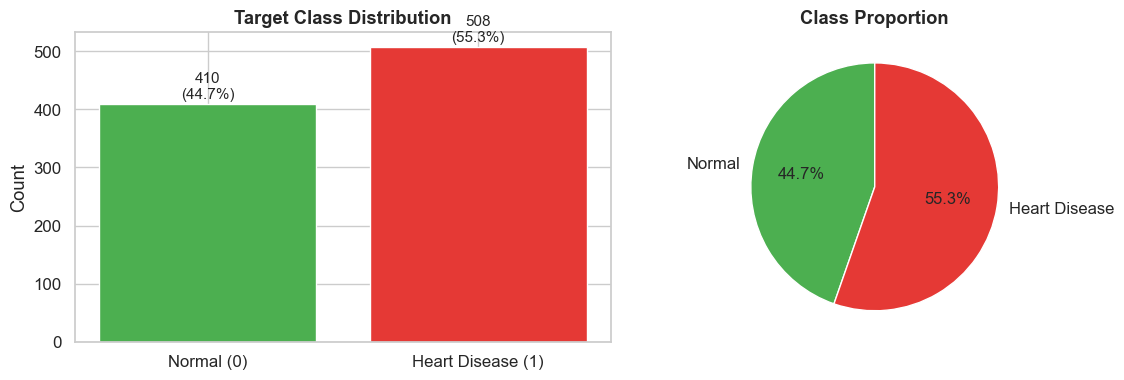


Interpretation: Moderate imbalance (~55/45 split). This justifies stratified
splitting and class weighting, but not aggressive resampling like SMOTE.


In [5]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100

print("Target class distribution:")
print(f"  Heart Disease Present (1): {target_counts[1]} ({target_pct[1]:.1f}%)")
print(f"  Normal (0):                {target_counts[0]} ({target_pct[0]:.1f}%)")
print(f"  Imbalance ratio:           {target_counts[1]/target_counts[0]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ["#4CAF50", "#E53935"]
bars = axes[0].bar(["Normal (0)", "Heart Disease (1)"], target_counts.values[::-1], color=colors)
axes[0].set_title("Target Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, count, pct in zip(bars, target_counts.values[::-1], target_pct.values[::-1]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f"{count}\n({pct:.1f}%)", ha="center", fontsize=11)

# Pie chart
axes[1].pie(target_counts.values[::-1], labels=["Normal", "Heart Disease"],
            colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Proportion", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nInterpretation: Moderate imbalance (~55/45 split). This justifies stratified")
print("splitting and class weighting, but not aggressive resampling like SMOTE.")

## Section 3: Univariate Analysis: Numeric Features

(Age, RestingBP, Cholesterol, MaxHR, Oldpeak)


  Age
              count   mean   std   min   25%   50%   75%   max
HeartDisease                                                  
0             410.0  50.55  9.44  28.0  43.0  51.0  57.0  76.0
1             508.0  55.90  8.73  31.0  51.0  57.0  62.0  77.0

  RestingBP
              count    mean    std   min    25%    50%    75%    max
HeartDisease                                                        
0             410.0  130.18  16.50  80.0  120.0  130.0  140.0  190.0
1             508.0  134.19  19.83   0.0  120.0  132.0  145.0  200.0

  Cholesterol
              count    mean     std  min     25%    50%     75%    max
HeartDisease                                                          
0             410.0  227.12   74.63  0.0  197.25  227.0  266.75  564.0
1             508.0  175.94  126.39  0.0    0.00  217.0  267.00  603.0

  MaxHR
              count    mean    std   min    25%    50%     75%    max
HeartDisease                                                         
0   

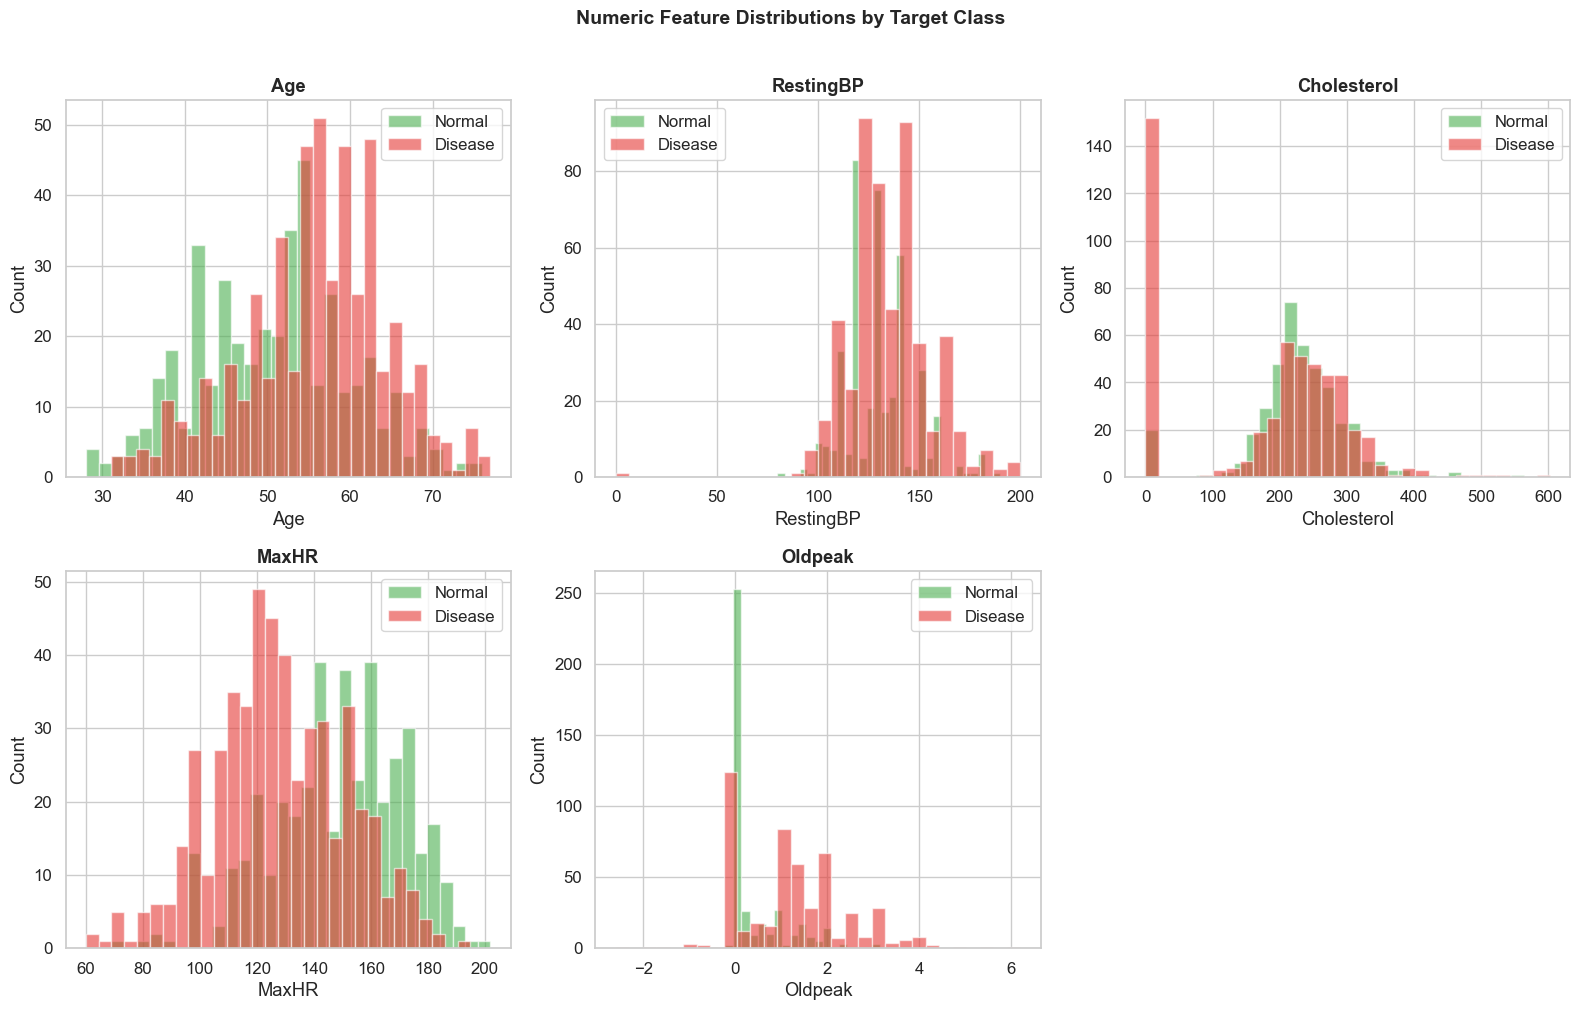

In [6]:
# Summary statistics by target class
for feat in NUMERIC_FEATURES:
    print(f"\n{'='*50}")
    print(f"  {feat}")
    print(f"{'='*50}")
    print(df.groupby(TARGET)[feat].describe().round(2))

# Distribution histograms segmented by target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    for label, color in [(0, "#4CAF50"), (1, "#E53935")]:
        subset = df[df[TARGET] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f"{'Normal' if label == 0 else 'Disease'}", edgecolor="white")
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend()

axes[-1].set_visible(False)  # Hide extra subplot
plt.suptitle("Numeric Feature Distributions by Target Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_19480\1560094234.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Disease"])
C:\Users\USER\AppData\Local\Temp\ipykernel_19480\1560094234.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Disease"])
C:\Users\USER\AppData\Local\Temp\ipykernel_19480\1560094234.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Disease"])
C:\Users\USER\AppData\Local\Temp\ipykernel_19480\1560094234.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Disease"])
C:\Users\USER\AppData\Local\

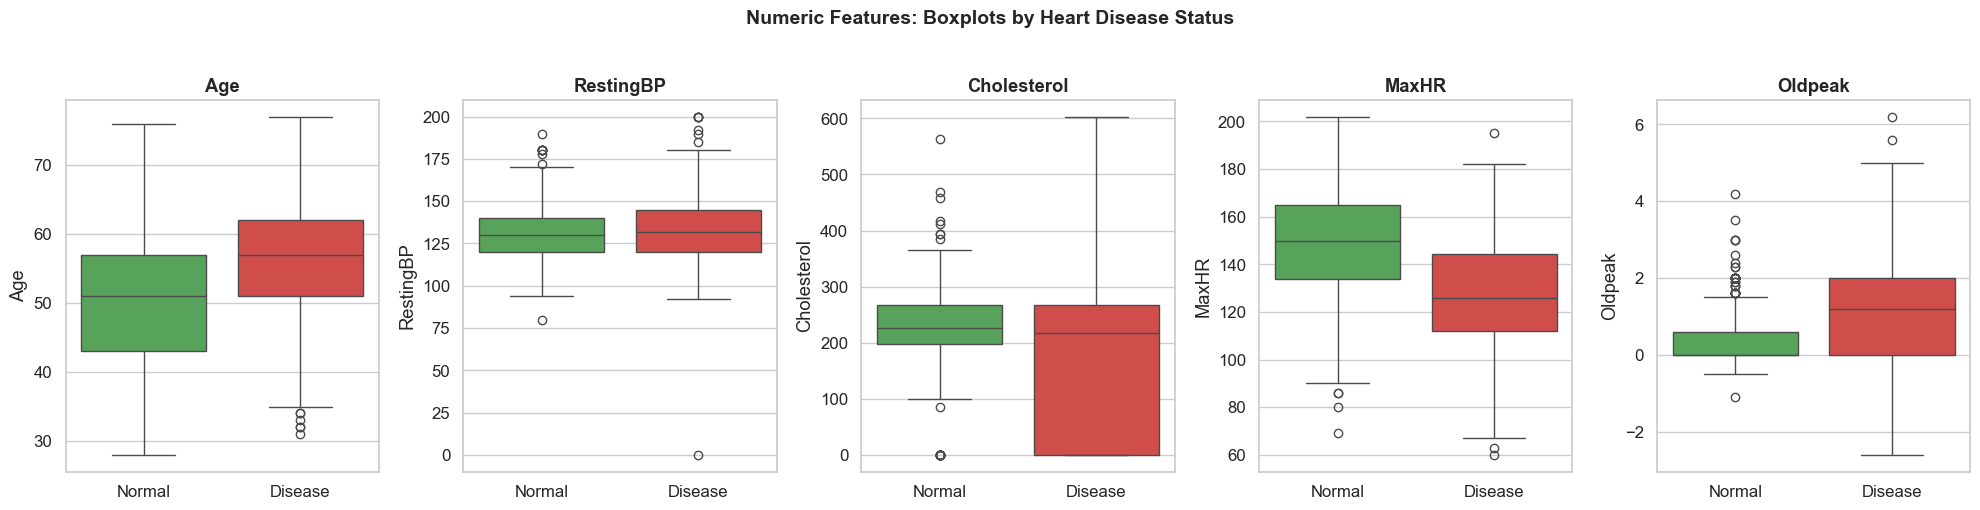

Key observations:
- Age: Disease patients tend to be older (median ~56 vs ~50)
- MaxHR: Disease patients achieve lower max heart rates (strong separator)
- Oldpeak: Disease patients show higher ST depression values
- Cholesterol: Large spike at 0 (missing values, addressed in Section 5)
- RestingBP: Similar distributions, less discriminative


In [7]:
# Boxplots by target class
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, feat in enumerate(NUMERIC_FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feat, ax=axes[i],
                palette={0: "#4CAF50", 1: "#E53935"}, hue=TARGET, legend=False)
    axes[i].set_title(feat, fontweight="bold")
    axes[i].set_xticklabels(["Normal", "Disease"])
    axes[i].set_xlabel("")

plt.suptitle("Numeric Features: Boxplots by Heart Disease Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/numeric_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key observations:")
print("- Age: Disease patients tend to be older (median ~56 vs ~50)")
print("- MaxHR: Disease patients achieve lower max heart rates (strong separator)")
print("- Oldpeak: Disease patients show higher ST depression values")
print("- Cholesterol: Large spike at 0 (missing values, addressed in Section 5)")
print("- RestingBP: Similar distributions, less discriminative")

## Section 4: Univariate Analysis: Categorical Features

(Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope, FastingBS)

In [8]:
cat_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]

# Cross-tabulations with heart disease rate
for feat in cat_features:
    ct = pd.crosstab(df[feat], df[TARGET], margins=True)
    ct_pct = pd.crosstab(df[feat], df[TARGET], normalize="index") * 100
    print(f"\n{'='*50}")
    print(f"  {feat} vs Heart Disease")
    print(f"{'='*50}")
    print(ct)
    print(f"\n% Heart Disease by {feat}:")
    print(ct_pct[1].round(1))


  Sex vs Heart Disease
HeartDisease    0    1  All
Sex                        
F             143   50  193
M             267  458  725
All           410  508  918

% Heart Disease by Sex:
Sex
F    25.9
M    63.2
Name: 1, dtype: float64

  ChestPainType vs Heart Disease
HeartDisease     0    1  All
ChestPainType               
ASY            104  392  496
ATA            149   24  173
NAP            131   72  203
TA              26   20   46
All            410  508  918

% Heart Disease by ChestPainType:
ChestPainType
ASY    79.0
ATA    13.9
NAP    35.5
TA     43.5
Name: 1, dtype: float64

  RestingECG vs Heart Disease
HeartDisease    0    1  All
RestingECG                 
LVH            82  106  188
Normal        267  285  552
ST             61  117  178
All           410  508  918

% Heart Disease by RestingECG:
RestingECG
LVH       56.4
Normal    51.6
ST        65.7
Name: 1, dtype: float64

  ExerciseAngina vs Heart Disease
HeartDisease      0    1  All
ExerciseAngina               

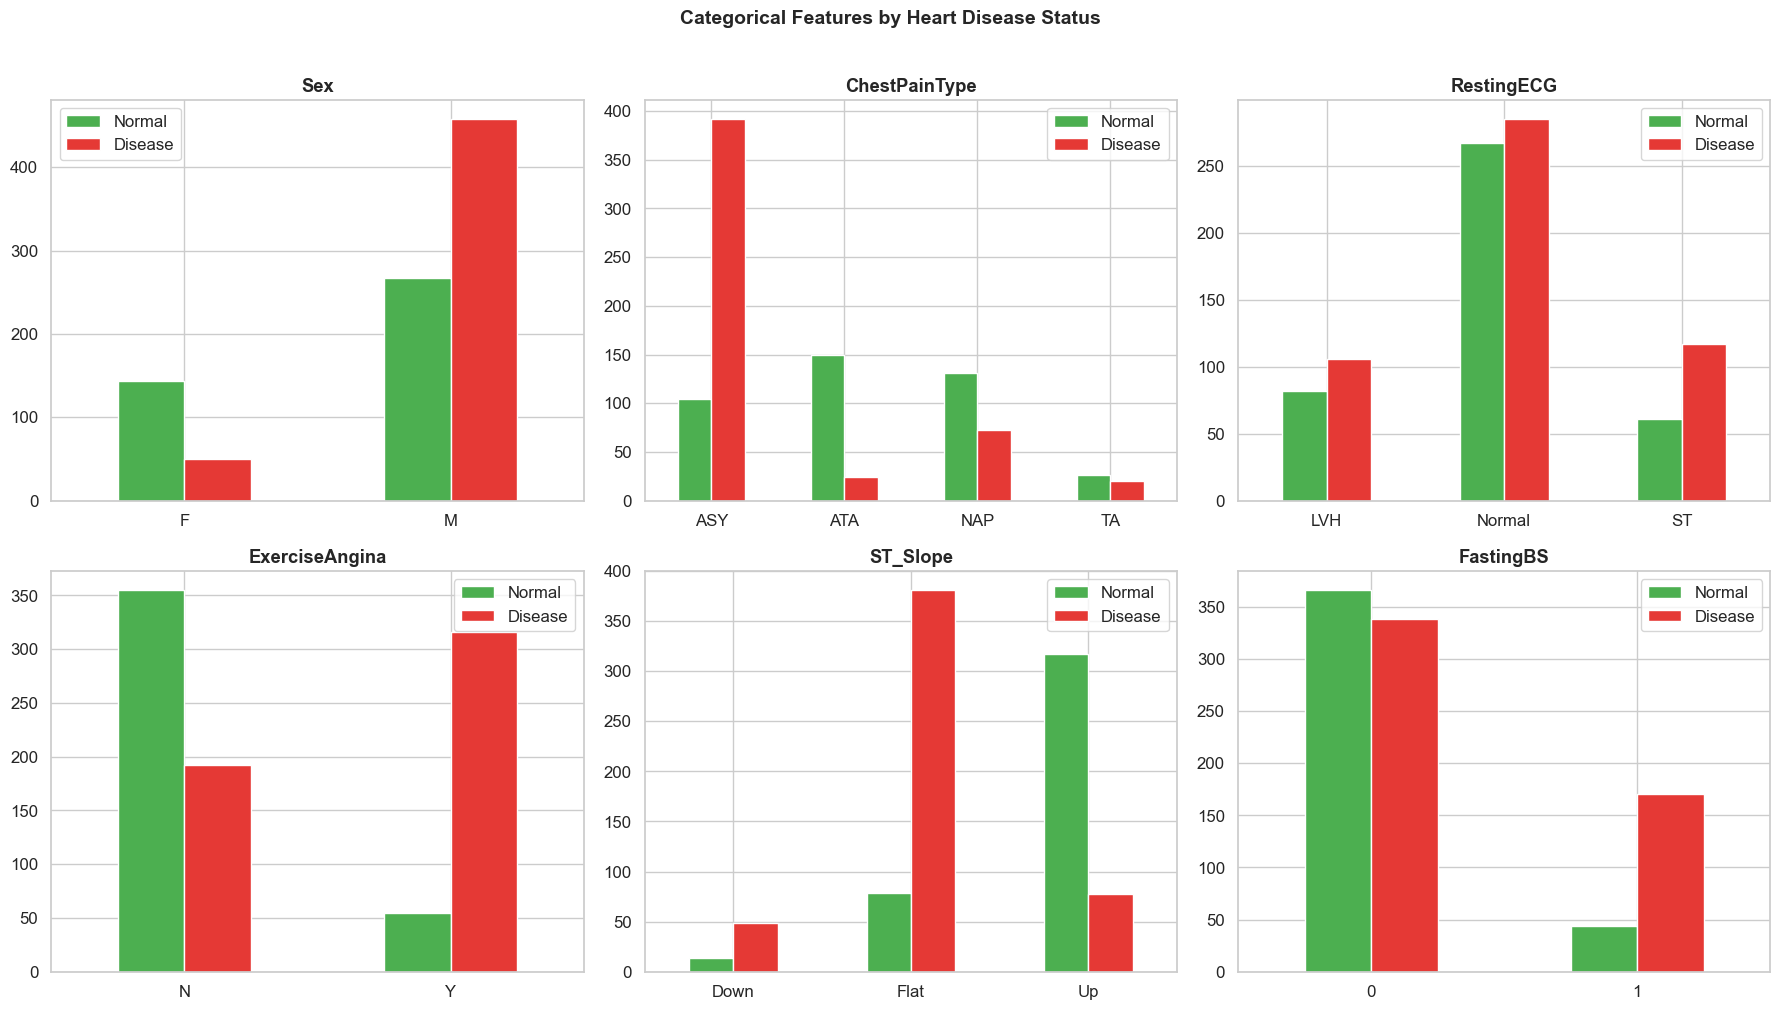


Key observations:
- ChestPainType: ASY (asymptomatic) has the highest disease rate (~79%)
- ExerciseAngina: 'Yes' strongly associated with disease (~77%)
- ST_Slope: 'Flat' strongly associated with disease (~78%); 'Up' is protective
- Sex: Males have higher disease rate than females
- FastingBS: Elevated fasting blood sugar (1) associated with higher disease rate


In [9]:
# Grouped bar charts for categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df[TARGET])
    ct.columns = ["Normal", "Disease"]
    ct.plot(kind="bar", ax=ax, color=["#4CAF50", "#E53935"], edgecolor="white", rot=0)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(title="")

plt.suptitle("Categorical Features by Heart Disease Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey observations:")
print("- ChestPainType: ASY (asymptomatic) has the highest disease rate (~79%)")
print("- ExerciseAngina: 'Yes' strongly associated with disease (~77%)")
print("- ST_Slope: 'Flat' strongly associated with disease (~78%); 'Up' is protective")
print("- Sex: Males have higher disease rate than females")
print("- FastingBS: Elevated fasting blood sugar (1) associated with higher disease rate")

## Section 5: Zero-Value & Missing Data Audit

Cholesterol and RestingBP contain clinically implausible zero values that represent missing data.

Cholesterol: 172 zero values (18.7% of dataset)
RestingBP: 1 zero values (0.1% of dataset)


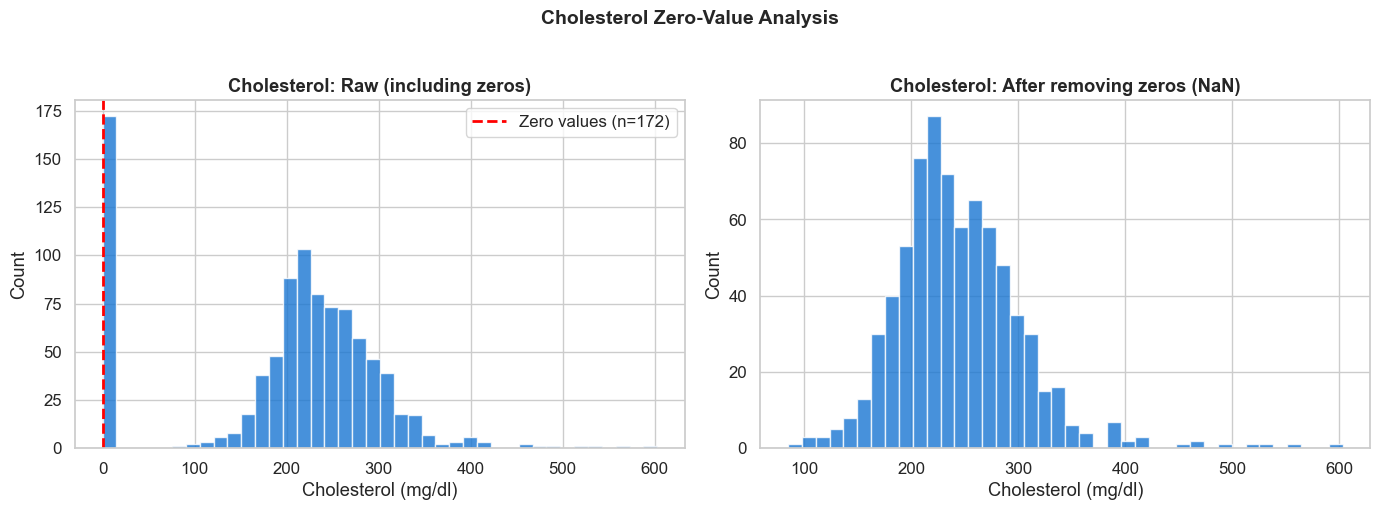


Cholesterol median (excluding zeros): 237 mg/dl
Cholesterol mean (excluding zeros): 244.6 mg/dl

RestingBP zero values: 1 record(s)

Decision: Replace Cholesterol=0 and RestingBP=0 with NaN.
Impute via median within the sklearn pipeline (fitted on training data only).


In [10]:
# Zero-value audit
for col in ZERO_AS_MISSING:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f"{col}: {n_zeros} zero values ({pct:.1f}% of dataset)")

# Cholesterol distribution before and after zero exclusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Cholesterol"], bins=40, color="#1976D2", edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2, label=f"Zero values (n={172})")
axes[0].set_title("Cholesterol: Raw (including zeros)", fontweight="bold")
axes[0].set_xlabel("Cholesterol (mg/dl)")
axes[0].set_ylabel("Count")
axes[0].legend()

df_clean = replace_zero_with_nan(df)
axes[1].hist(df_clean["Cholesterol"].dropna(), bins=40, color="#1976D2", edgecolor="white", alpha=0.8)
axes[1].set_title("Cholesterol: After removing zeros (NaN)", fontweight="bold")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Count")

plt.suptitle("Cholesterol Zero-Value Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/cholesterol_zero_audit.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCholesterol median (excluding zeros): {df_clean['Cholesterol'].median():.0f} mg/dl")
print(f"Cholesterol mean (excluding zeros): {df_clean['Cholesterol'].mean():.1f} mg/dl")
print(f"\nRestingBP zero values: {(df['RestingBP'] == 0).sum()} record(s)")
print("\nDecision: Replace Cholesterol=0 and RestingBP=0 with NaN.")
print("Impute via median within the sklearn pipeline (fitted on training data only).")

## Section 6: Outlier Detection

Using the IQR method on all numeric features.

Outlier Detection Summary (IQR method, 1.5x):

    Feature  Lower Bound  Upper Bound  N Outliers  % Outliers
        Age         27.5         79.5           0         0.0
  RestingBP         90.0        170.0          27         2.9
Cholesterol        105.6        376.6          23         3.1
      MaxHR         66.0        210.0           2         0.2
    Oldpeak         -2.2          3.8          16         1.7


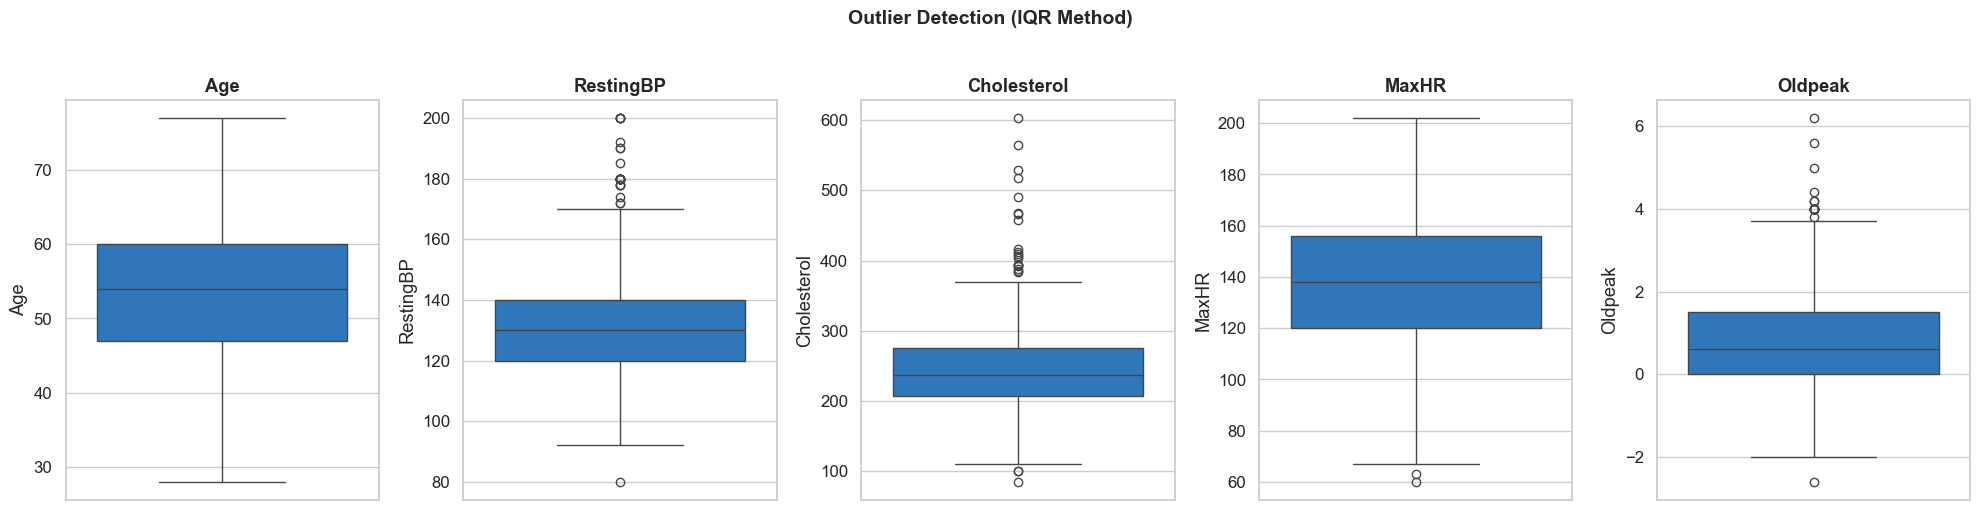


Decision: Document outliers but do NOT remove them.
Rationale: Tree-based models (RF, XGBoost) are robust to outliers.
Removing outliers may bias the dataset and lose clinically valid extreme cases.


In [11]:
# Use df_clean (zeros replaced with NaN) for outlier detection
outlier_summary = []
for feat in NUMERIC_FEATURES:
    series = df_clean[feat].dropna()
    lower, upper, n_out, mask = detect_outliers_iqr(series)
    pct = n_out / len(series) * 100
    outlier_summary.append({
        "Feature": feat,
        "Lower Bound": round(lower, 1),
        "Upper Bound": round(upper, 1),
        "N Outliers": n_out,
        "% Outliers": round(pct, 1),
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Detection Summary (IQR method, 1.5x):\n")
print(outlier_df.to_string(index=False))

# Boxplot visualization
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, feat in enumerate(NUMERIC_FEATURES):
    sns.boxplot(data=df_clean, y=feat, ax=axes[i], color="#1976D2")
    axes[i].set_title(feat, fontweight="bold")

plt.suptitle("Outlier Detection (IQR Method)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDecision: Document outliers but do NOT remove them.")
print("Rationale: Tree-based models (RF, XGBoost) are robust to outliers.")
print("Removing outliers may bias the dataset and lose clinically valid extreme cases.")

## Section 7: Bivariate & Correlation Analysis

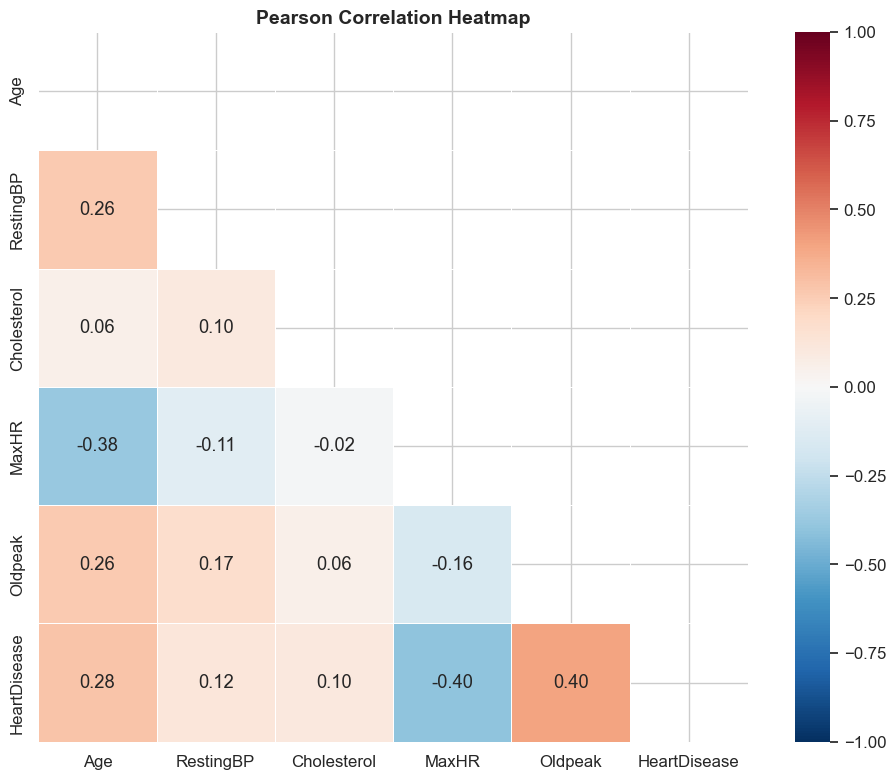

Feature pairs with |r| > 0.50:


In [12]:
# Pearson correlation heatmap (numeric features + target)
corr_cols = NUMERIC_FEATURES + [TARGET]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Heatmap", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag high correlations
print("Feature pairs with |r| > 0.50:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.50:
            print(f"  {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: r = {r:.3f}")

C:\Users\USER\AppData\Local\Temp\ipykernel_19480\2449440452.py:10: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[0].legend(*scatter.legend_elements(), labels=["Normal", "Disease"])


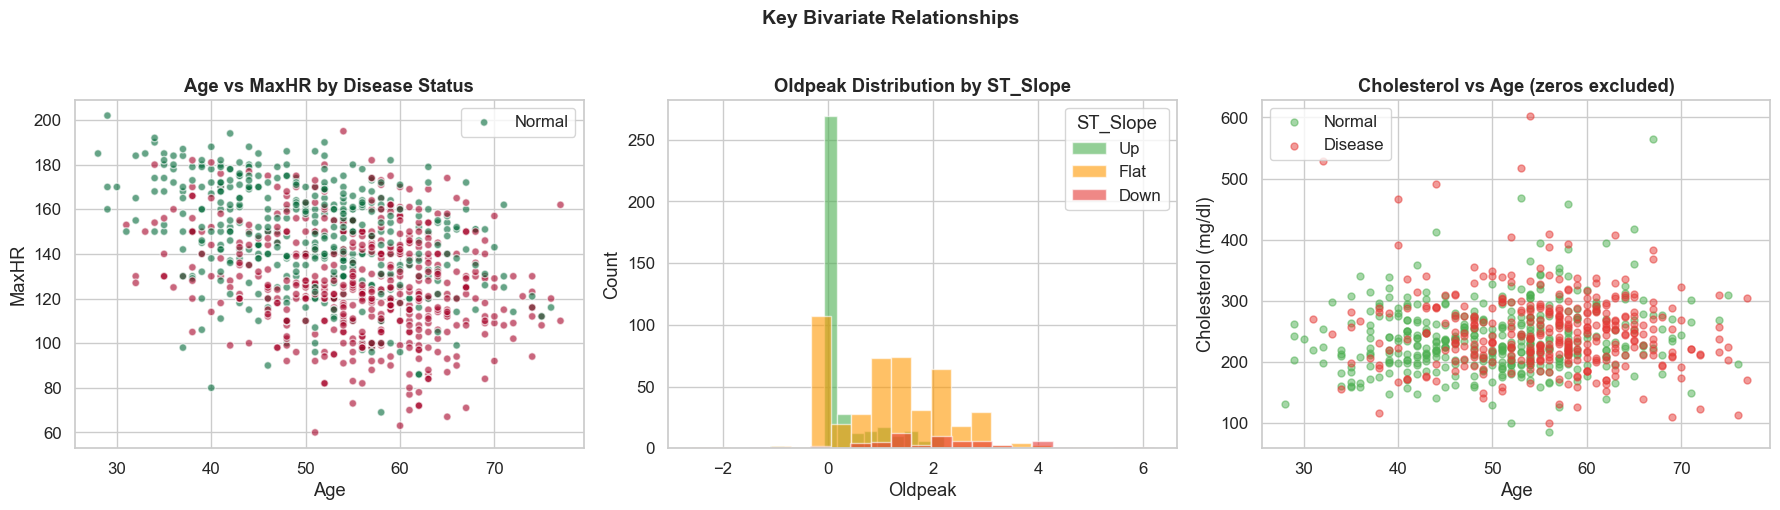

In [13]:
# Key bivariate plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs MaxHR colored by target
scatter = axes[0].scatter(df["Age"], df["MaxHR"], c=df[TARGET],
                          cmap="RdYlGn_r", alpha=0.6, edgecolors="white", s=30)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("MaxHR")
axes[0].set_title("Age vs MaxHR by Disease Status", fontweight="bold")
axes[0].legend(*scatter.legend_elements(), labels=["Normal", "Disease"])

# Oldpeak distribution by ST_Slope
for slope, color in [("Up", "#4CAF50"), ("Flat", "#FF9800"), ("Down", "#E53935")]:
    subset = df[df["ST_Slope"] == slope]["Oldpeak"]
    axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=slope, edgecolor="white")
axes[1].set_xlabel("Oldpeak")
axes[1].set_ylabel("Count")
axes[1].set_title("Oldpeak Distribution by ST_Slope", fontweight="bold")
axes[1].legend(title="ST_Slope")

# Cholesterol vs Age by target (excluding zeros)
df_nonzero = df[df["Cholesterol"] > 0]
for label, color, name in [(0, "#4CAF50", "Normal"), (1, "#E53935", "Disease")]:
    sub = df_nonzero[df_nonzero[TARGET] == label]
    axes[2].scatter(sub["Age"], sub["Cholesterol"], c=color, alpha=0.5, label=name, s=25)
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Cholesterol (mg/dl)")
axes[2].set_title("Cholesterol vs Age (zeros excluded)", fontweight="bold")
axes[2].legend()

plt.suptitle("Key Bivariate Relationships", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/bivariate_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8: Multicollinearity Check (VIF)

In [14]:
# VIF on numeric features (using cleaned data, zeros replaced with NaN then dropped)
vif_df = compute_vif(df_clean[NUMERIC_FEATURES].dropna())
print("Variance Inflation Factor (VIF) Analysis:\n")
print(vif_df.to_string(index=False))
print("\nThreshold: VIF > 5 indicates concerning multicollinearity.")

high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nFeatures with VIF > 5:")
    for _, row in high_vif.iterrows():
        print(f"  {row['feature']}: VIF = {row['VIF']}")
    print("\nImplication: LR coefficients for these features should be interpreted with caution.")
else:
    print("\nNo features exceed VIF = 5. Multicollinearity is not a concern for LR.")

Variance Inflation Factor (VIF) Analysis:

    feature   VIF
  RestingBP 49.19
        Age 30.26
      MaxHR 22.35
Cholesterol 17.13
    Oldpeak  1.95

Threshold: VIF > 5 indicates concerning multicollinearity.

Features with VIF > 5:
  RestingBP: VIF = 49.19
  Age: VIF = 30.26
  MaxHR: VIF = 22.35
  Cholesterol: VIF = 17.13

Implication: LR coefficients for these features should be interpreted with caution.


## Section 9: Key EDA Takeaways

In [15]:
takeaways = """
KEY EDA TAKEAWAYS
=================

1. TARGET DISTRIBUTION: Moderate imbalance (55.3% disease / 44.7% normal).
   Justifies stratified splitting and class weighting, not aggressive resampling.

2. STRONGEST DISCRIMINATORS:
   - ST_Slope (Flat strongly associated with disease)
   - ChestPainType (ASY = ~79% disease rate)
   - ExerciseAngina (Yes = ~77% disease rate)
   - MaxHR (disease patients achieve lower max heart rates)
   - Oldpeak (higher ST depression in disease patients)

3. DATA QUALITY - CHOLESTEROL:
   172 records (18.7%) have Cholesterol=0, representing missing data from
   Hungarian and Swiss subsets. These will be replaced with NaN and imputed
   via median within the sklearn pipeline.

4. DATA QUALITY - RESTINGBP:
   1 record has RestingBP=0. Same treatment: replace with NaN, median impute.

5. OUTLIERS:
   Present in RestingBP (high values) and Cholesterol (after zero removal).
   Decision: retain outliers. Tree-based models are robust, and extreme values
   may be clinically valid.

6. MULTICOLLINEARITY:
   Age and MaxHR show moderate negative correlation (~-0.38).
   VIF analysis will confirm whether this is concerning for LR interpretation.

7. FEATURES REQUIRING STRESS TESTING:
   MaxHR, ExerciseAngina, Oldpeak, ST_Slope require exercise stress testing.
   These are among the strongest predictors but are unavailable at HC III/IV.
   The reduced-feature experiment will quantify the performance impact.
"""
print(takeaways)


KEY EDA TAKEAWAYS

1. TARGET DISTRIBUTION: Moderate imbalance (55.3% disease / 44.7% normal).
   Justifies stratified splitting and class weighting, not aggressive resampling.

2. STRONGEST DISCRIMINATORS:
   - ST_Slope (Flat strongly associated with disease)
   - ChestPainType (ASY = ~79% disease rate)
   - ExerciseAngina (Yes = ~77% disease rate)
   - MaxHR (disease patients achieve lower max heart rates)
   - Oldpeak (higher ST depression in disease patients)

3. DATA QUALITY - CHOLESTEROL:
   172 records (18.7%) have Cholesterol=0, representing missing data from
   Hungarian and Swiss subsets. These will be replaced with NaN and imputed
   via median within the sklearn pipeline.

4. DATA QUALITY - RESTINGBP:
   1 record has RestingBP=0. Same treatment: replace with NaN, median impute.

5. OUTLIERS:
   Present in RestingBP (high values) and Cholesterol (after zero removal).
   Decision: retain outliers. Tree-based models are robust, and extreme values
   may be clinically valid.

6

## Section 10: Save EDA Artifacts

Export summaries and data for the Streamlit Data Insights page.

In [16]:
from src.artifacts import save_json, save_dataframe

# Save EDA summary for Streamlit
eda_summary = {
    "n_records": int(df.shape[0]),
    "n_features": int(df.shape[1] - 1),
    "target_counts": {
        "disease": int(target_counts[1]),
        "normal": int(target_counts[0]),
    },
    "target_pct": {
        "disease": round(float(target_pct[1]), 1),
        "normal": round(float(target_pct[0]), 1),
    },
    "cholesterol_zeros": int((df["Cholesterol"] == 0).sum()),
    "restingbp_zeros": int((df["RestingBP"] == 0).sum()),
    "cholesterol_median_clean": round(float(df_clean["Cholesterol"].median()), 1),
    "duplicates": int(df.duplicated().sum()),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": cat_features,
    "stress_test_features": STRESS_TEST_FEATURES,
    "routine_care_features": ROUTINE_CARE_FEATURES,
}
save_json(eda_summary, "../outputs/app_assets", "eda_summary.json")

# Save outlier summary
save_dataframe(outlier_df, "../outputs/tables", "outlier_summary.csv")

# Save VIF results
save_dataframe(vif_df, "../outputs/tables", "vif_results.csv")

# Save correlation matrix
save_dataframe(corr_matrix.reset_index(), "../outputs/tables", "correlation_matrix.csv")

print("\nAll EDA artifacts saved successfully.")
print(f"  Figures: ../outputs/figures/")
print(f"  Tables:  ../outputs/tables/")
print(f"  Assets:  ../outputs/app_assets/")

Saved JSON: ..\outputs\app_assets\eda_summary.json
Saved CSV: ..\outputs\tables\outlier_summary.csv
Saved CSV: ..\outputs\tables\vif_results.csv
Saved CSV: ..\outputs\tables\correlation_matrix.csv

All EDA artifacts saved successfully.
  Figures: ../outputs/figures/
  Tables:  ../outputs/tables/
  Assets:  ../outputs/app_assets/
